# Задача 6. BFS on GPU

**ФИО:** Непомнящий Матвей Тимофеевич  
**ИСУ:** 507189  
**Группа:** S4102


## Задача

Реализовать обход в ширину (BFS) ориентированного графа на GPU через OpenCL и сравнить с CPU на графах разного размера из SuiteSparse.


## Импорты

PyOpenCL для GPU, SciPy CSR для графа, matplotlib для графиков.

Зависимости: `pip install pyopencl scipy pandas matplotlib`. Нужен OpenCL-драйвер GPU (на Windows обычно ставится вместе с драйвером NVIDIA).


In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100

import numpy as np
import pyopencl as cl
from scipy.io import mmread
from scipy.sparse import csr_matrix
from collections import deque
import time
import os
import urllib.request
import tarfile
import ssl
import pandas as pd


Загрузка графов из SuiteSparse.


Пути к кэшу и `download_graph`: скачиваем `.tar.gz`, распаковываем в `DOWNLOAD_DIR`.


In [2]:
DOWNLOAD_DIR = os.path.abspath(os.path.join("..", "data", "suitesparse"))
BASE_URL = "https://suitesparse-collection-website.herokuapp.com/MM"


def download_graph(group: str, name: str) -> str:
    graph_dir = os.path.join(DOWNLOAD_DIR, name)
    mtx_path = os.path.join(graph_dir, f"{name}.mtx")
    if os.path.exists(mtx_path):
        return mtx_path

    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    url = f"{BASE_URL}/{group}/{name}.tar.gz"
    tar_path = os.path.join(DOWNLOAD_DIR, f"{name}.tar.gz")
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE

    print(f"  Downloading {group}/{name} ...")
    req = urllib.request.Request(url)
    with urllib.request.urlopen(req, context=ctx, timeout=120) as resp:
        with open(tar_path, "wb") as f:
            f.write(resp.read())

    with tarfile.open(tar_path, "r:gz") as tf:
        tf.extractall(DOWNLOAD_DIR)
    os.remove(tar_path)

    if not os.path.exists(mtx_path):
        for root, _, files in os.walk(graph_dir):
            for f in files:
                if f.endswith(".mtx"):
                    return os.path.join(root, f)
    return mtx_path


`load_graph_csr` и `load_suitesparse_csr`: читаем Matrix Market и возвращаем CSR.


In [3]:
def load_graph_csr(path: str) -> csr_matrix:
    return csr_matrix(mmread(path))


def load_suitesparse_csr(group: str, name: str) -> csr_matrix:
    return load_graph_csr(download_graph(group, name))


`load_local_csr`: локальные `.mtx` из `lab_2/graphs_for_test/` (для тестов).


In [4]:
LOCAL_GRAPH_ROOT = os.path.abspath(os.path.join("..", "lab_2", "graphs_for_test"))


def load_local_csr(rel_path: str) -> csr_matrix:
    path = os.path.join(LOCAL_GRAPH_ROOT, *rel_path.split("/"))
    return load_graph_csr(path)


## Задание 1. BFS на GPU

Сначала CPU-версия для сверки, затем OpenCL-реализация.


`bfs_cpu`: классический BFS с очередью на CSR-графе.


In [5]:
def bfs_cpu(adj: csr_matrix, source: int) -> np.ndarray:
    n = adj.shape[0]
    distances = np.full(n, -1, dtype=np.int32)
    distances[source] = 0

    indptr = adj.indptr
    indices = adj.indices
    queue = deque([source])

    while queue:
        v = queue.popleft()
        d = distances[v]
        for j in range(indptr[v], indptr[v + 1]):
            u = indices[j]
            if distances[u] == -1:
                distances[u] = d + 1
                queue.append(u)

    return distances


OpenCL-ядро: на каждом уровне параллельно обходим вершины текущего фронта. Граф храним в CSR (`row_offsets`, `col_indices`).


In [6]:
BFS_KERNEL_SRC = r"""
__kernel void bfs_kernel(
    __global const int *row_offsets,
    __global const int *col_indices,
    __global int       *distances,
    __global const int *frontier,
    __global int       *next_frontier,
    __global int       *frontier_changed,
    const int n,
    const int level)
{
    int tid = get_global_id(0);
    if (tid >= n) return;
    if (frontier[tid] != 1) return;

    int row_start = row_offsets[tid];
    int row_end   = row_offsets[tid + 1];

    for (int j = row_start; j < row_end; j++) {
        int neighbor = col_indices[j];
        if (distances[neighbor] == -1) {
            distances[neighbor] = level + 1;
            next_frontier[neighbor] = 1;
            frontier_changed[0] = 1;
        }
    }
}
"""


Инициализация OpenCL: ищем GPU (если нет — CPU), создаём контекст и компилируем `bfs_kernel`.


In [7]:
def init_opencl():
    try:
        platforms = cl.get_platforms()
    except cl.LogicError as e:
        raise RuntimeError(
            "OpenCL-платформы не найдены. Установите pyopencl и OpenCL-драйвер для GPU "
            "(NVIDIA/AMD/Intel)."
        ) from e

    for dtype in (cl.device_type.GPU, cl.device_type.ACCELERATOR, cl.device_type.CPU):
        for platform in platforms:
            try:
                devices = platform.get_devices(device_type=dtype)
            except cl.LogicError:
                continue
            if devices:
                device = devices[0]
                ctx = cl.Context(devices=[device])
                queue = cl.CommandQueue(ctx, properties=cl.command_queue_properties.PROFILING_ENABLE)
                return ctx, queue, device

    raise RuntimeError("OpenCL-устройства не найдены на доступных платформах.")


ctx, queue, ocl_device = init_opencl()
program = cl.Program(ctx, BFS_KERNEL_SRC).build()
bfs_kernel = cl.Kernel(program, "bfs_kernel")
print(f"OpenCL platform: {ocl_device.platform.name}")
print(f"OpenCL device: {ocl_device.name} ({cl.device_type.to_string(ocl_device.type)})")


OpenCL platform: NVIDIA CUDA
OpenCL device: NVIDIA GeForce RTX 4060 Laptop GPU (ALL | GPU)


`bfs_gpu`: host-обёртка — копируем CSR на устройство, по уровням запускаем ядро, возвращаем расстояния.


In [8]:
def bfs_gpu(adj: csr_matrix, source: int,
            cl_ctx=None, cl_queue=None, kernel=None) -> np.ndarray:
    if cl_ctx is None:
        cl_ctx = ctx
    if cl_queue is None:
        cl_queue = queue
    if kernel is None:
        kernel = bfs_kernel

    n = adj.shape[0]
    mf = cl.mem_flags

    row_offsets = adj.indptr.astype(np.int32)
    col_indices = adj.indices.astype(np.int32)
    distances = np.full(n, -1, dtype=np.int32)
    distances[source] = 0
    frontier = np.zeros(n, dtype=np.int32)
    frontier[source] = 1
    next_frontier = np.zeros(n, dtype=np.int32)
    frontier_changed = np.zeros(1, dtype=np.int32)

    buf_row = cl.Buffer(cl_ctx, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=row_offsets)
    buf_col = cl.Buffer(cl_ctx, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=col_indices)
    buf_dist = cl.Buffer(cl_ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=distances)
    buf_front = cl.Buffer(cl_ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=frontier)
    buf_next = cl.Buffer(cl_ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=next_frontier)
    buf_changed = cl.Buffer(cl_ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=frontier_changed)

    global_size = ((n + 255) // 256) * 256
    level = 0
    while True:
        frontier_changed[0] = 0
        cl.enqueue_copy(cl_queue, buf_changed, frontier_changed)
        kernel(cl_queue, (global_size,), (256,),
               buf_row, buf_col, buf_dist,
               buf_front, buf_next, buf_changed,
               np.int32(n), np.int32(level))
        cl_queue.finish()

        cl.enqueue_copy(cl_queue, frontier_changed, buf_changed)
        if frontier_changed[0] == 0:
            break

        buf_front, buf_next = buf_next, buf_front
        next_frontier[:] = 0
        cl.enqueue_copy(cl_queue, buf_next, next_frontier)
        level += 1

    cl.enqueue_copy(cl_queue, distances, buf_dist)
    return distances


### Тест корректности

Сравним CPU и GPU BFS на небольшом графе `ca-GrQc`.


`load_test_graph`: граф `ca-GrQc` из `lab_2/graphs_for_test/` (если файла нет — `airfoil1` из SuiteSparse).


In [9]:
def load_test_graph():
    local_path = os.path.join(LOCAL_GRAPH_ROOT, "ca-GrQc", "ca-GrQc.mtx")
    if os.path.exists(local_path):
        return load_local_csr("ca-GrQc/ca-GrQc.mtx"), "ca-GrQc"
    return load_suitesparse_csr("AG-Monien", "airfoil1"), "airfoil1"


Сравниваем расстояния CPU и GPU для нескольких стартовых вершин.


In [10]:
test_graph, test_name = load_test_graph()
print(f"Test graph ({test_name}): {test_graph.shape[0]} vertices, {test_graph.nnz} edges")

all_ok = True
for src in [0, 1, 10, min(100, test_graph.shape[0] - 1)]:
    dist_cpu = bfs_cpu(test_graph, src)
    dist_gpu = bfs_gpu(test_graph, src)
    match = np.array_equal(dist_cpu, dist_gpu)
    print(f"  source={src:3d}: CPU == GPU -> {match}")
    all_ok &= match

print("Validation OK" if all_ok else "Validation FAILED")


Test graph (ca-GrQc): 5242 vertices, 28980 edges
  source=  0: CPU == GPU -> True
  source=  1: CPU == GPU -> True
  source= 10: CPU == GPU -> True
  source=100: CPU == GPU -> True
Validation OK


### Выводы (задание 1)

GPU BFS возвращает те же расстояния, что и CPU, на графе `ca-GrQc` (5242 вершины, 28980 рёбер) для всех проверенных стартовых вершин.


## Задание 2. Сравнение CPU и GPU

Замерим среднее время BFS из нескольких стартовых вершин на графах разного размера из SuiteSparse. Для GPU отдельно считаем передачу данных и вычисления.


Список графов для бенчмарка: от малых сеточных до крупных web-графов SNAP.


In [11]:
SUITESPARSE_GRAPHS = [
    ("AG-Monien", "airfoil1"),
    ("AG-Monien", "crack"),
    ("SNAP", "p2p-Gnutella31"),
    ("SNAP", "web-NotreDame"),
    ("SNAP", "web-Google"),
]


`bfs_gpu_transfer_split`: тот же BFS на GPU, но отдельно замеряем передачу host→device, цикл ядра и device→host.


In [12]:
def bfs_gpu_transfer_split(adj: csr_matrix, source: int,
                           cl_ctx=None, cl_queue=None, kernel=None):
    if cl_ctx is None:
        cl_ctx = ctx
    if cl_queue is None:
        cl_queue = queue
    if kernel is None:
        kernel = bfs_kernel

    n = adj.shape[0]
    mf = cl.mem_flags
    row_offsets = adj.indptr.astype(np.int32)
    col_indices = adj.indices.astype(np.int32)
    distances = np.full(n, -1, dtype=np.int32)
    distances[source] = 0
    frontier = np.zeros(n, dtype=np.int32)
    frontier[source] = 1
    next_frontier = np.zeros(n, dtype=np.int32)
    frontier_changed = np.zeros(1, dtype=np.int32)

    t_transfer_start = time.perf_counter()
    buf_row = cl.Buffer(cl_ctx, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=row_offsets)
    buf_col = cl.Buffer(cl_ctx, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=col_indices)
    buf_dist = cl.Buffer(cl_ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=distances)
    buf_front = cl.Buffer(cl_ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=frontier)
    buf_next = cl.Buffer(cl_ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=next_frontier)
    buf_changed = cl.Buffer(cl_ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=frontier_changed)
    cl_queue.finish()
    t_transfer_h2d = time.perf_counter() - t_transfer_start

    global_size = ((n + 255) // 256) * 256
    level = 0
    t_compute_start = time.perf_counter()
    while True:
        frontier_changed[0] = 0
        cl.enqueue_copy(cl_queue, buf_changed, frontier_changed)
        kernel(cl_queue, (global_size,), (256,),
               buf_row, buf_col, buf_dist,
               buf_front, buf_next, buf_changed,
               np.int32(n), np.int32(level))
        cl_queue.finish()
        cl.enqueue_copy(cl_queue, frontier_changed, buf_changed)
        if frontier_changed[0] == 0:
            break
        buf_front, buf_next = buf_next, buf_front
        next_frontier[:] = 0
        cl.enqueue_copy(cl_queue, buf_next, next_frontier)
        level += 1
    t_compute = time.perf_counter() - t_compute_start

    t_d2h_start = time.perf_counter()
    cl.enqueue_copy(cl_queue, distances, buf_dist)
    cl_queue.finish()
    t_transfer_d2h = time.perf_counter() - t_d2h_start

    return distances, t_transfer_h2d + t_transfer_d2h, t_compute


`pick_sources`: берём несколько стартовых вершин с ненулевой исходящей степенью, равномерно по индексу.


In [13]:
def pick_sources(adj: csr_matrix, count: int = 5) -> list[int]:
    out_deg = np.diff(adj.indptr)
    candidates = np.where(out_deg > 0)[0]
    if len(candidates) == 0:
        return [0]
    step = max(1, len(candidates) // count)
    return candidates[::step][:count].tolist()


`benchmark_graph`: для каждой стартовой вершины считаем CPU и GPU, усредняем и возвращаем speedup.


In [14]:
def benchmark_graph(adj: csr_matrix, name: str, n_sources: int = 5) -> dict:
    sources = pick_sources(adj, n_sources)
    cpu_times, gpu_total_times, gpu_compute_times, gpu_transfer_times = [], [], [], []

    for src in sources:
        t0 = time.perf_counter()
        _ = bfs_cpu(adj, src)
        cpu_times.append(time.perf_counter() - t0)

        _, t_transfer, t_compute = bfs_gpu_transfer_split(adj, src)
        gpu_total_times.append(t_transfer + t_compute)
        gpu_compute_times.append(t_compute)
        gpu_transfer_times.append(t_transfer)

    cpu_mean = float(np.mean(cpu_times))
    gpu_total_mean = float(np.mean(gpu_total_times))
    gpu_compute_mean = float(np.mean(gpu_compute_times))
    return {
        "graph": name,
        "vertices": adj.shape[0],
        "edges": adj.nnz,
        "cpu_mean_s": cpu_mean,
        "gpu_total_mean_s": gpu_total_mean,
        "gpu_compute_mean_s": gpu_compute_mean,
        "gpu_transfer_mean_s": float(np.mean(gpu_transfer_times)),
        "speedup_total": cpu_mean / gpu_total_mean if gpu_total_mean > 0 else 0.0,
        "speedup_compute": cpu_mean / gpu_compute_mean if gpu_compute_mean > 0 else 0.0,
    }


Запускаем бенчмарк на графах из списка, печатаем время и собираем таблицу `df`.


In [15]:
results = []
for group, name in SUITESPARSE_GRAPHS:
    try:
        adj = load_suitesparse_csr(group, name)
        print(f"\n{name}: {adj.shape[0]:,} vertices, {adj.nnz:,} edges")
        res = benchmark_graph(adj, name)
        results.append(res)
        print(f"  CPU:  {res['cpu_mean_s']:.4f} s")
        print(f"  GPU total:   {res['gpu_total_mean_s']:.4f} s  (speedup {res['speedup_total']:.2f}x)")
        print(f"  GPU compute: {res['gpu_compute_mean_s']:.4f} s  (speedup {res['speedup_compute']:.2f}x)")
    except Exception as e:
        print(f"\n{name}: skip ({e})")

df = pd.DataFrame(results)
df



airfoil1: 4,253 vertices, 24,578 edges


  CPU:  0.0101 s
  GPU total:   0.0133 s  (speedup 0.76x)
  GPU compute: 0.0132 s  (speedup 0.77x)

crack: 10,240 vertices, 60,760 edges


  CPU:  0.0217 s
  GPU total:   0.0218 s  (speedup 0.99x)
  GPU compute: 0.0216 s  (speedup 1.00x)

p2p-Gnutella31: 62,586 vertices, 147,892 edges


  CPU:  0.1153 s
  GPU total:   0.0091 s  (speedup 12.73x)
  GPU compute: 0.0087 s  (speedup 13.29x)

web-NotreDame: 325,729 vertices, 1,497,134 edges


  CPU:  0.5763 s
  GPU total:   0.0277 s  (speedup 20.81x)
  GPU compute: 0.0252 s  (speedup 22.86x)



web-Google: 916,428 vertices, 5,105,039 edges


  CPU:  1.4713 s
  GPU total:   0.0803 s  (speedup 18.32x)
  GPU compute: 0.0734 s  (speedup 20.03x)


,graph,vertices,edges,cpu_mean_s,gpu_total_mean_s,gpu_compute_mean_s,gpu_transfer_mean_s,speedup_total,speedup_compute
0,airfoil1,4253,24578,0.010107,0.013262,0.013163,0.000098,0.762153,0.767847
1,crack,10240,60760,0.021663,0.021784,0.021648,0.000136,0.994457,1.000708
2,p2p-Gnutella31,62586,147892,0.115349,0.009065,0.008677,0.000387,12.725326,13.293154
3,web-NotreDame,325729,1497134,0.576321,0.027691,0.025209,0.002482,20.812955,22.862029
4,web-Google,916428,5105039,1.471291,0.080319,0.073437,0.006881,18.318144,20.034644


### Визуализация

Время CPU vs GPU и speedup по графам из `df` (график в ноутбуке).


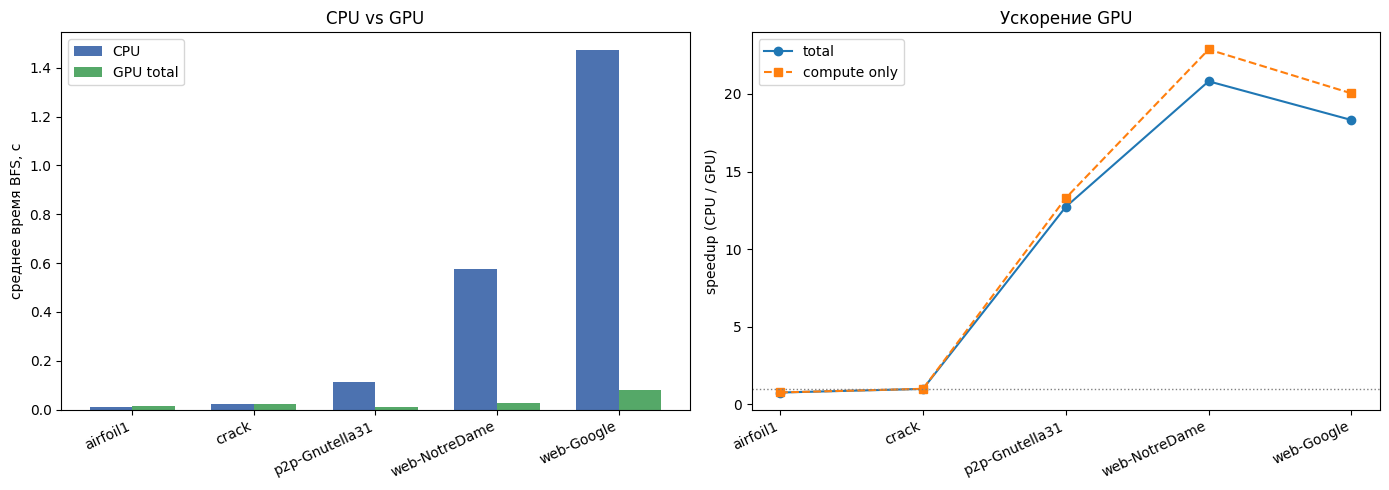

In [16]:
if len(df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    x = np.arange(len(df))
    w = 0.35
    ax.bar(x - w / 2, df["cpu_mean_s"], w, label="CPU", color="#4c72b0")
    ax.bar(x + w / 2, df["gpu_total_mean_s"], w, label="GPU total", color="#55a868")
    ax.set_xticks(x)
    ax.set_xticklabels(df["graph"], rotation=25, ha="right")
    ax.set_ylabel("среднее время BFS, с")
    ax.set_title("CPU vs GPU")
    ax.legend()

    ax = axes[1]
    ax.plot(df["graph"], df["speedup_total"], "o-", label="total")
    ax.plot(df["graph"], df["speedup_compute"], "s--", label="compute only")
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(df["graph"], rotation=25, ha="right")
    ax.set_ylabel("speedup (CPU / GPU)")
    ax.set_title("Ускорение GPU")
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No benchmark results")


Отдельно смотрим долю времени GPU на вычисления и на передачу данных.


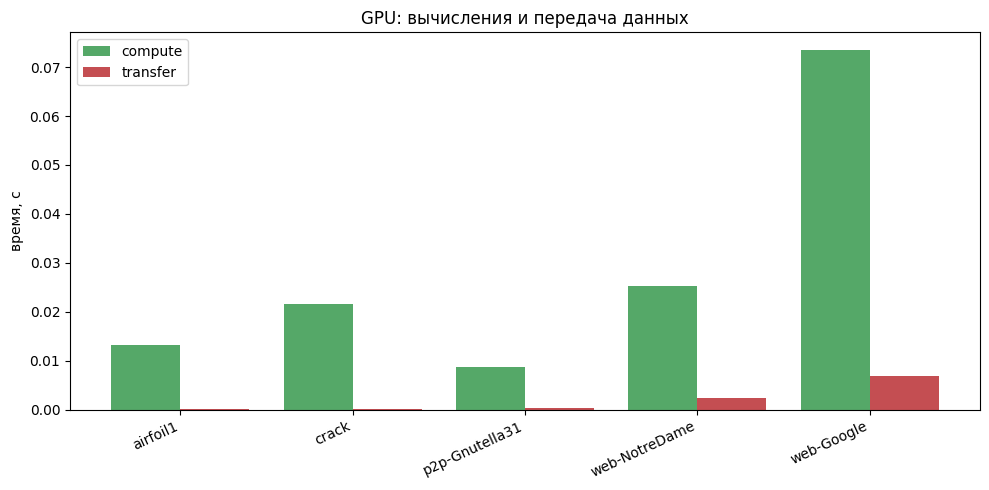

In [17]:
if len(df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df))
    ax.bar(x - 0.2, df["gpu_compute_mean_s"], 0.4, label="compute", color="#55a868")
    ax.bar(x + 0.2, df["gpu_transfer_mean_s"], 0.4, label="transfer", color="#c44e52")
    ax.set_xticks(x)
    ax.set_xticklabels(df["graph"], rotation=25, ha="right")
    ax.set_ylabel("время, с")
    ax.set_title("GPU: вычисления и передача данных")
    ax.legend()
    plt.tight_layout()
    plt.show()


### Выводы (задание 2)

Сравнили BFS на 5 графах SuiteSparse (таблица `df`, графики выше):

1. `airfoil1` (4,253 вершин): CPU 0.0101 с, GPU 0.0133 с, speedup 0.76x.
2. `crack` (10,240 вершин): CPU 0.0217 с, GPU 0.0218 с, speedup 0.99x.
3. `p2p-Gnutella31` (62,586 вершин): CPU 0.1153 с, GPU 0.0091 с, speedup 12.73x.
4. `web-NotreDame` (325,729 вершин): CPU 0.5763 с, GPU 0.0277 с, speedup 20.81x.
5. `web-Google` (916,428 вершин): CPU 1.4713 с, GPU 0.0803 с, speedup 18.32x.

На малых графах (`airfoil1`, `crack`) GPU не быстрее CPU: накладные расходы OpenCL перевешивают выигрыш.
На крупных графах GPU быстрее: максимум на `web-NotreDame` (speedup 20.81x). Ускорение (speedup > 1) на 3 из 5 графов.
Доля передачи данных растёт с размером графа (на web-Google около 9% времени GPU, см. график compute vs transfer).


## Общий вывод

Реализовали BFS на GPU через OpenCL (NVIDIA GeForce RTX 4060) и сравнили с CPU на графах SuiteSparse разного размера. Расстояния совпадают. На крупных разреженных графах есть ускорение (до 21x на `web-NotreDame`), на маленьких GPU медленнее из-за запуска ядра и копирования данных.
